## 1-  Install required libraries

In [1]:
import sys
!{sys.executable} -m pip install tensorflow-cpu

  Using cached tensorflow_cpu-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 2.1/351.2 MB 4.3 MB/s eta 0:01:21
   ---------------------------------------- 2.9/351.2 MB 4.4 MB/s eta 0:01:19
   ---------------------------------------- 3.9/351.2 MB 4.5 MB/s eta 0:01:18
   ---------------------------------------- 3.9/351.2 MB 4.5 MB/s eta 0:01:18
    --------------------------------------- 5.2/351.2 MB 4.0 MB/s eta 0:01:27
    --------------------------------------- 6.3/351.2 MB 4.1 MB/s eta 0:01:25
    --------------------------------------- 7.1/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 7.6/351.2 MB 4.2 MB/s eta 0:01:23
   -

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\zahra\\anaconda3\\Lib\\site-packages\\tensorflow\\compiler\\mlir\\lite\\python\\_pywrap_converter_api.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
import sys
!{sys.executable} -m pip install tensorflow

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2- Data Preparation


In [6]:
import sys
!{sys.executable} -m pip install kagglehub



   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



## 1- install essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## installing project folders and sub_folders


In [2]:
import os

# Create project subfolders
folders = ['data', 'visualizations', 'models', 'reports']
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Folder created: {folder}/')

print('\nProject structure ready!')

Folder created: data/
Folder created: visualizations/
Folder created: models/
Folder created: reports/

Project structure ready!


In [3]:
import os

# Point to your Desktop folder
project_path = r'C:\Users\zahra\Desktop\Stock_Prediction_Project'
os.chdir(project_path)

# Make sure all subfolders exist
for folder in ['data', 'visualizations', 'models', 'reports']:
    os.makedirs(folder, exist_ok=True)

print('Working directory:', os.getcwd())
print('All subfolders ready!')
    

Working directory: C:\Users\zahra\Desktop\Stock_Prediction_Project
All subfolders ready!


## 2- Data Preparation


In [4]:
import kagglehub
import os

# Download the dataset
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")
print("Path to dataset files:", path)

# See what files are available
files = os.listdir(path)
print("\nFiles available:", files[:10])  # show first 10

100%|██████████| 522M/522M [02:21<00:00, 3.87MB/s] 

Extracting files...


Path to dataset files: C:\Users\zahra\.cache\kagglehub\datasets\jacksoncrow\stock-market-dataset\versions\2

Files available: ['etfs', 'stocks', 'symbols_valid_meta.csv']


In [5]:
# Choose any stock ticker available in the dataset
ticker = "AAPL"

# Load the CSV for that ticker
# The files are usually inside a subfolder called 'stocks' or 'etfs'
stock_path = os.path.join(path, "stocks", f"{ticker}.csv")

# If the above doesn't work, try:
# stock_path = os.path.join(path, f"{ticker}.csv")

df = pd.read_csv(stock_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Loaded {len(df)} rows for {ticker}")
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("\nColumns:", df.columns.tolist())
df.head()

Loaded 9909 rows for AAPL
Date range: 1980-12-12 00:00:00 to 2020-04-01 00:00:00

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [6]:
df.to_csv(f"data/{ticker}_historical.csv", index=False)
print(f"Saved to data/{ticker}_historical.csv")

Saved to data/AAPL_historical.csv


## 3- Data Expolation

## 3.a - Structural Overview

In [7]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDate range:', df['Date'].min(), 'to', df['Date'].max())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (9909, 7)

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Date range: 1980-12-12 00:00:00 to 2020-04-01 00:00:00

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [8]:
# Descriptive statistics
print('Descriptive Statistics:')
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)

Descriptive Statistics:


,Open,High,Low,Close,Volume
count,9909.00,9909.00,9909.00,9909.00,9.909000e+03
mean,32.61,32.94,32.28,32.62,8.582916e+07
std,58.42,59.00,57.88,58.47,8.597195e+07
min,0.20,0.20,0.20,0.20,3.472000e+05
25%,1.07,1.09,1.05,1.07,3.304230e+07
50%,1.73,1.76,1.70,1.73,5.766490e+07
75%,35.80,36.27,35.33,35.76,1.069992e+08
max,324.74,327.85,323.35,327.20,1.855410e+09


## 3.b- Price History & Volume Chart

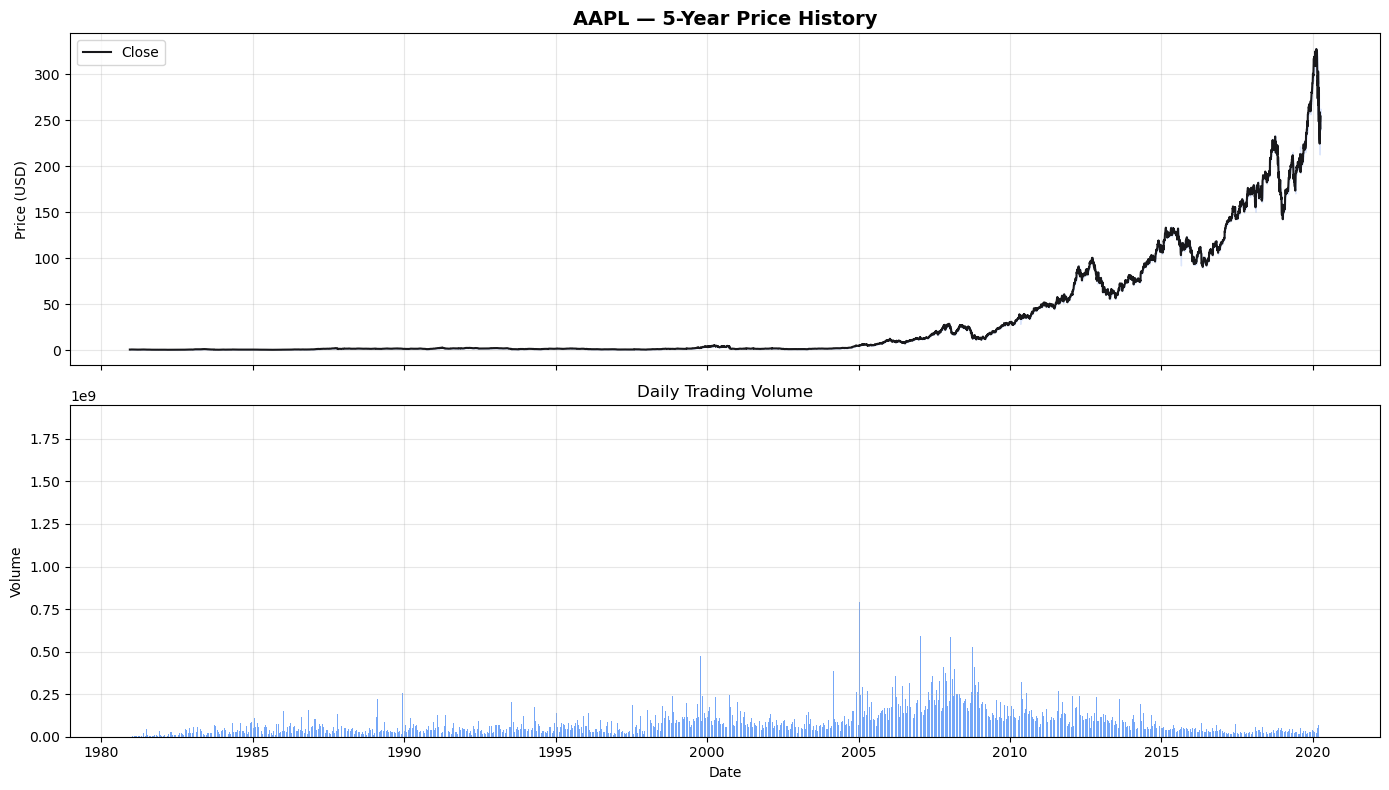

Chart saved to visualizations/price_history.png


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price chart
ax1.plot(df['Date'], df['Close'], color='#18181B', linewidth=1.5, label='Close')
ax1.fill_between(df['Date'], df['Low'], df['High'], alpha=0.15, color='#2563EB')
ax1.set_title(f'{ticker} — 5-Year Price History', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(alpha=0.3)

# Volume bar chart
ax2.bar(df['Date'], df['Volume'], color='#3B82F6', alpha=0.7, width=1)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.set_title('Daily Trading Volume', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/price_history.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved to visualizations/price_history.png')

## 3.c- Correlation heatmap


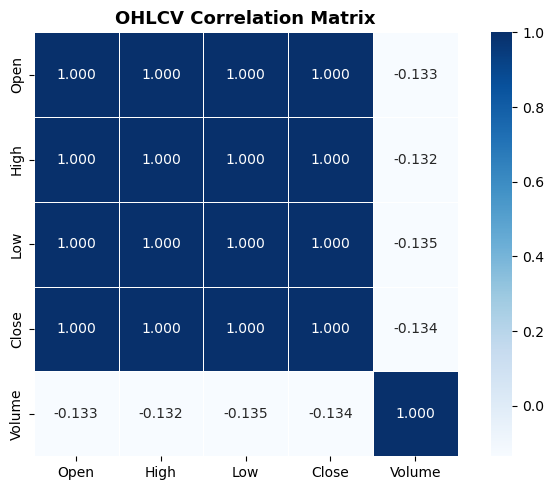

Heatmap saved to visualizations/correlation_heatmap.png


In [10]:
# Flatten multi-level columns if yfinance returned them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if col[1] == '' else col[0] for col in df.columns]

corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5, square=True)
plt.title('OHLCV Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Heatmap saved to visualizations/correlation_heatmap.png')

## 4- data cleaning


In [11]:
# Work on a clean copy
df2 = df.copy().set_index('Date').sort_index()

# Flatten columns if needed
df2.columns = [col[0] if isinstance(col, tuple) else col for col in df2.columns]

print('Starting feature engineering...')
print('Initial shape:', df2.shape)

Starting feature engineering...
Initial shape: (9909, 6)


In [12]:
# ── Trend Features ──────────────────────────────────────────────────────────
df2['SMA_20'] = df2['Close'].rolling(20).mean()       # 20-day simple moving avg
df2['SMA_50'] = df2['Close'].rolling(50).mean()       # 50-day simple moving avg
df2['EMA_12'] = df2['Close'].ewm(span=12).mean()      # 12-day exponential moving avg
df2['EMA_26'] = df2['Close'].ewm(span=26).mean()      # 26-day exponential moving avg
df2['MACD']   = df2['EMA_12'] - df2['EMA_26']         # MACD line

print('Trend features created: SMA_20, SMA_50, EMA_12, EMA_26, MACD')

Trend features created: SMA_20, SMA_50, EMA_12, EMA_26, MACD


In [13]:
# ── Volatility Features (Bollinger Bands) ────────────────────────────────────
rolling20      = df2['Close'].rolling(20)
df2['BB_mid']  = rolling20.mean()
df2['BB_upper']= rolling20.mean() + 2 * rolling20.std()
df2['BB_lower']= rolling20.mean() - 2 * rolling20.std()
df2['BB_width']= df2['BB_upper'] - df2['BB_lower']    # bandwidth = volatility proxy

print('Volatility features created: BB_mid, BB_upper, BB_lower, BB_width')

Volatility features created: BB_mid, BB_upper, BB_lower, BB_width


In [14]:
# ── Momentum Feature: RSI ────────────────────────────────────────────────────
delta       = df2['Close'].diff()
gain        = delta.clip(lower=0).rolling(14).mean()
loss        = (-delta.clip(upper=0)).rolling(14).mean()
rs          = gain / loss
df2['RSI']  = 100 - (100 / (1 + rs))

print('Momentum feature created: RSI')

Momentum feature created: RSI


In [15]:
# ── Lag Features ─────────────────────────────────────────────────────────────
for lag in [1, 2, 3, 5, 10, 20]:
    df2[f'Close_lag_{lag}'] = df2['Close'].shift(lag)

print('Lag features created: Close_lag_1, 2, 3, 5, 10, 20')

Lag features created: Close_lag_1, 2, 3, 5, 10, 20


In [16]:
# ── Price Return Features ─────────────────────────────────────────────────────
df2['Daily_Return']  = df2['Close'].pct_change()
df2['Weekly_Return'] = df2['Close'].pct_change(5)
df2['HL_Spread']     = df2['High'] - df2['Low']       # daily range
df2['OC_Spread']     = df2['Close'] - df2['Open']     # body direction

# Drop rows with NaN (caused by rolling windows)
df2.dropna(inplace=True)

print(f'\nDataset shape after feature engineering: {df2.shape}')
print(f'Features: {df2.columns.tolist()}')


Dataset shape after feature engineering: (9860, 26)
Features: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'BB_mid', 'BB_upper', 'BB_lower', 'BB_width', 'RSI', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10', 'Close_lag_20', 'Daily_Return', 'Weekly_Return', 'HL_Spread', 'OC_Spread']


In [17]:
# Preview the engineered dataset
df2.head()

,Open,High,Low,Close,Adj Close,Volume,SMA_20,SMA_50,EMA_12,EMA_26,...,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_5,Close_lag_10,Close_lag_20,Daily_Return,Weekly_Return,HL_Spread,OC_Spread
Date,,,,,,,,,,,,,,,,,,,,,
1981-02-24,0.428571,0.428571,0.424107,0.424107,0.336037,4244800,0.487054,0.530312,0.463869,0.491979,...,0.439732,0.433036,0.457589,0.466518,0.486607,0.575893,-0.035533,-0.090909,0.004464,-0.004464
1981-02-25,0.450893,0.453125,0.450893,0.450893,0.357260,4872000,0.481027,0.529062,0.461872,0.488874,...,0.424107,0.439732,0.433036,0.486607,0.486607,0.571429,0.063158,-0.073394,0.002232,0.000000
1981-02-26,0.457589,0.459821,0.457589,0.457589,0.362566,2710400,0.476228,0.528482,0.461213,0.486513,...,0.450893,0.424107,0.439732,0.457589,0.470982,0.553571,0.014851,0.000000,0.002232,0.000000
1981-02-27,0.473214,0.477679,0.473214,0.473214,0.374946,3690400,0.473214,0.528929,0.463060,0.485511,...,0.457589,0.450893,0.424107,0.433036,0.466518,0.533482,0.034146,0.092784,0.004464,0.000000
1981-03-02,0.475446,0.477679,0.475446,0.475446,0.376715,2940000,0.471763,0.529196,0.464965,0.484754,...,0.473214,0.457589,0.450893,0.439732,0.455357,0.504464,0.004717,0.081218,0.002232,0.000000


## 5- Define Target Variable & Scale Features

In [18]:
# Target: next day closing price
df2['Target'] = df2['Close'].shift(-1)
df2.dropna(inplace=True)  # remove last row (no target)

print('Target variable created: next-day Close price')
print('Dataset shape after adding target:', df2.shape)

Target variable created: next-day Close price
Dataset shape after adding target: (9859, 27)


In [19]:
# Feature columns — exclude Target and raw OHLCV to avoid leakage
feature_cols = [c for c in df2.columns if c not in ['Target', 'Open', 'High', 'Low', 'Volume']]

X_raw = df2[feature_cols].values
y_raw = df2['Target'].values

print(f'Number of features: {len(feature_cols)}')
print('Feature columns:', feature_cols)

Number of features: 22
Feature columns: ['Close', 'Adj Close', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'BB_mid', 'BB_upper', 'BB_lower', 'BB_width', 'RSI', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10', 'Close_lag_20', 'Daily_Return', 'Weekly_Return', 'HL_Spread', 'OC_Spread']


In [20]:
# Scale features to [0, 1]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

print(f'X_scaled shape: {X_scaled.shape}')
print(f'X_scaled range: [{X_scaled.min():.4f}, {X_scaled.max():.4f}]')
print(f'y_scaled range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]')

X_scaled shape: (9859, 22)
X_scaled range: [0.0000, 1.0000]
y_scaled range: [0.0000, 1.0000]


## 6- Train / Test Split

In [21]:
# ── Linear Regression split (flat 2D features) ───────────────────────────────
split_idx = int(len(X_scaled) * 0.80)

X_train_lr, X_test_lr = X_scaled[:split_idx], X_scaled[split_idx:]
y_train_lr, y_test_lr = y_raw[:split_idx],    y_raw[split_idx:]

print(f'Linear Regression — Train: {X_train_lr.shape} | Test: {X_test_lr.shape}')

Linear Regression — Train: (7887, 22) | Test: (1972, 22)


In [22]:
# ── LSTM split (3D sequences: samples x timesteps x features) ────────────────
LOOKBACK = 60  # model looks at 60 previous days to predict the next

def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])  # 60-day window
        ys.append(y[i])             # next-day target
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, LOOKBACK)

split_seq = int(len(X_seq) * 0.80)
X_train_lstm, X_test_lstm = X_seq[:split_seq], X_seq[split_seq:]
y_train_lstm, y_test_lstm = y_seq[:split_seq], y_seq[split_seq:]

print(f'LSTM — Train: {X_train_lstm.shape} | Test: {X_test_lstm.shape}')
print(f'Shape means: (samples, lookback_days=60, features={X_train_lstm.shape[2]})')

LSTM — Train: (7839, 60, 22) | Test: (1960, 60, 22)
Shape means: (samples, lookback_days=60, features=22)


## 7- Train Linear Regression (Baseline Model)

In [23]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
print('Linear Regression trained successfully!')

Linear Regression trained successfully!


In [24]:
# Predict
lr_preds = lr_model.predict(X_test_lr)

# Metrics
lr_mae  = mean_absolute_error(y_test_lr, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test_lr, lr_preds))
lr_mape = np.mean(np.abs((y_test_lr - lr_preds) / y_test_lr)) * 100

print('=== LINEAR REGRESSION RESULTS ===')
print(f'MAE  (Mean Absolute Error)    : ${lr_mae:.2f}')
print(f'RMSE (Root Mean Squared Error): ${lr_rmse:.2f}')
print(f'MAPE (Mean Absolute % Error)  : {lr_mape:.2f}%')

=== LINEAR REGRESSION RESULTS ===
MAE  (Mean Absolute Error)    : $1.78
RMSE (Root Mean Squared Error): $3.08
MAPE (Mean Absolute % Error)  : 1.27%


In [25]:
# Top 10 most influential features by coefficient
coef_df = pd.Series(lr_model.coef_, index=feature_cols)\
            .abs().sort_values(ascending=False).head(10)

print('Top 10 most influential features (by |coefficient|):')
print(coef_df.round(4))

Top 10 most influential features (by |coefficient|):
Close           319.0312
EMA_26           79.0469
EMA_12           76.7575
SMA_50           47.0166
Close_lag_1      22.7357
Close_lag_20     18.7223
Close_lag_2      18.6816
Adj Close        16.3300
Close_lag_3      16.2714
Close_lag_5      14.6178
dtype: float64


## 8- Build & Train the LSTM Neural Network

In [26]:
# Set seed for reproducibility
tf.random.set_seed(42)

# Define LSTM architecture
lstm_model = Sequential([
    # First LSTM layer — return sequences so next LSTM gets full output
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, X_train_lstm.shape[2])),
    Dropout(0.2),   # randomly drop 20% of neurons — prevents overfitting

    # Second LSTM layer
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Dense output layers
    Dense(32, activation='relu'),
    Dense(1)        # single output: next-day close price (scaled)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,833 (503.25 KB)

 Trainable params: 128,833 (503.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'models/lstm_best.keras',
    monitor='val_loss',
    save_best_only=True
)

# Train
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.10,     # use last 10% of train for validation
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 2.4495e-04 - val_loss: 0.0011
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - loss: 1.8083e-05 - val_loss: 9.1919e-04
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 1.4921e-05 - val_loss: 9.2188e-04
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 1.0903e-05 - val_loss: 0.0011
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 9.2586e-06 - val_loss: 0.0015
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 8.2881e-06 - val_loss: 8.8567e-04
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 8.4668e-06 - val_loss: 8.6871e-04
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 6.9830e-06 - val_loss: 9.8087e-04
Epoch 9/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 6.4808e-06 - val_loss: 8.0028e-04
Epoch 10/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 5.9999e-06 - val_loss: 7.1656e-04
Epoch 11/100
221/221 ━━━━━━━━━━━━━━━━━━━━

## 9- Evaluate & Compare Both Models

In [28]:
# LSTM predictions — inverse-scale back to USD
lstm_preds_scaled   = lstm_model.predict(X_test_lstm)
lstm_preds          = scaler_y.inverse_transform(lstm_preds_scaled).flatten()
y_test_lstm_actual  = scaler_y.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

print('LSTM predictions generated and inverse-scaled to USD.')

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
LSTM predictions generated and inverse-scaled to USD.


In [29]:
# LSTM metrics
lstm_mae  = mean_absolute_error(y_test_lstm_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_actual, lstm_preds))
lstm_mape = np.mean(np.abs((y_test_lstm_actual - lstm_preds) / y_test_lstm_actual)) * 100

print('=== LSTM RESULTS ===')
print(f'MAE  : ${lstm_mae:.2f}')
print(f'RMSE : ${lstm_rmse:.2f}')
print(f'MAPE : {lstm_mape:.2f}%')

=== LSTM RESULTS ===
MAE  : $54.56
RMSE : $69.03
MAPE : 35.10%


In [30]:
# Full model comparison table
comparison = pd.DataFrame({
    'Model' : ['Linear Regression', 'LSTM'],
    'MAE ($)': [round(lr_mae, 2),   round(lstm_mae, 2)],
    'RMSE ($)': [round(lr_rmse, 2), round(lstm_rmse, 2)],
    'MAPE (%)': [round(lr_mape, 3), round(lstm_mape, 3)]
})

print('=== MODEL COMPARISON ===')
comparison

=== MODEL COMPARISON ===


,Model,MAE ($),RMSE ($),MAPE (%)
0,Linear Regression,1.78,3.08,1.272
1,LSTM,54.56,69.03,35.098


## 10- Visualise Results

## 10.1 - Four-Panel Dashboard (Predictions + Residuals + Loss Curve)

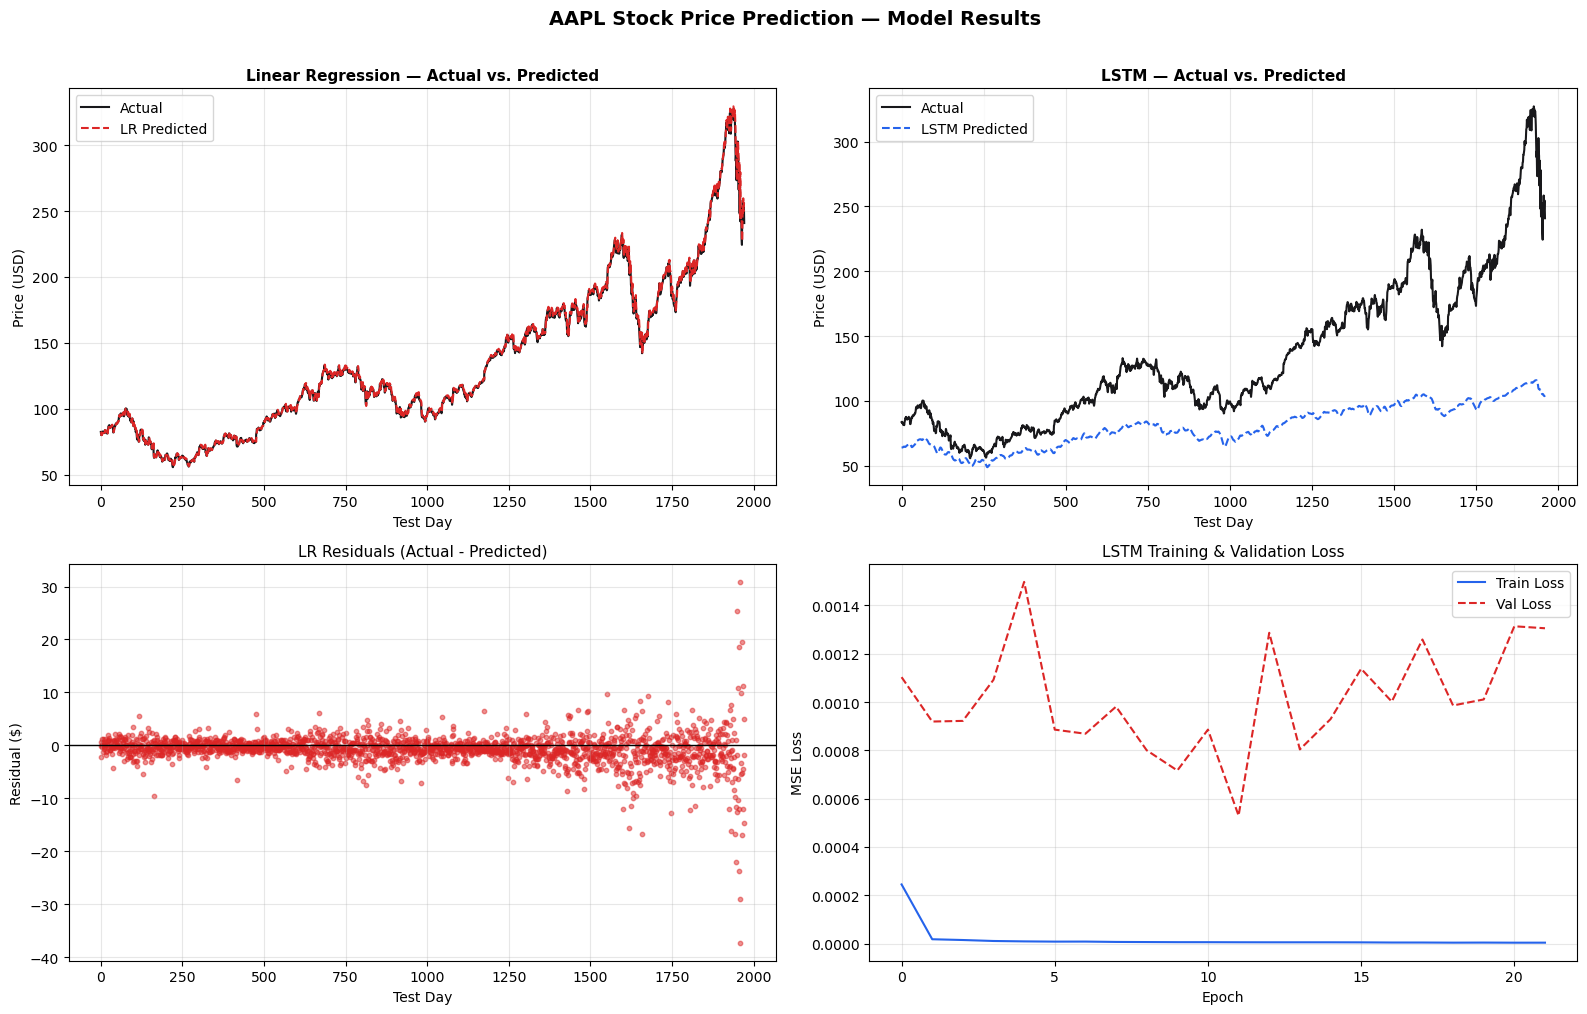

Chart saved to visualizations/prediction_results.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: Linear Regression predictions
axes[0,0].plot(y_test_lr,  color='#18181B', lw=1.5, label='Actual')
axes[0,0].plot(lr_preds,   color='#DC2626', lw=1.5, linestyle='--', label='LR Predicted')
axes[0,0].set_title('Linear Regression — Actual vs. Predicted', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Test Day')
axes[0,0].set_ylabel('Price (USD)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Top-right: LSTM predictions
axes[0,1].plot(y_test_lstm_actual, color='#18181B', lw=1.5, label='Actual')
axes[0,1].plot(lstm_preds,         color='#2563EB', lw=1.5, linestyle='--', label='LSTM Predicted')
axes[0,1].set_title('LSTM — Actual vs. Predicted', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Test Day')
axes[0,1].set_ylabel('Price (USD)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Bottom-left: LR residuals
lr_residuals = y_test_lr - lr_preds
axes[1,0].scatter(range(len(lr_residuals)), lr_residuals, alpha=0.5, color='#DC2626', s=10)
axes[1,0].axhline(0, color='black', lw=1)
axes[1,0].set_title('LR Residuals (Actual - Predicted)', fontsize=11)
axes[1,0].set_xlabel('Test Day')
axes[1,0].set_ylabel('Residual ($)')
axes[1,0].grid(alpha=0.3)

# Bottom-right: LSTM training loss curve
axes[1,1].plot(history.history['loss'],     label='Train Loss', color='#2563EB')
axes[1,1].plot(history.history['val_loss'], label='Val Loss',   color='#DC2626', linestyle='--')
axes[1,1].set_title('LSTM Training & Validation Loss', fontsize=11)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('MSE Loss')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle(f'{ticker} Stock Price Prediction — Model Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visualizations/prediction_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved to visualizations/prediction_results.png')

## 10.2 - RSI & Bollinger Bands Visualisation

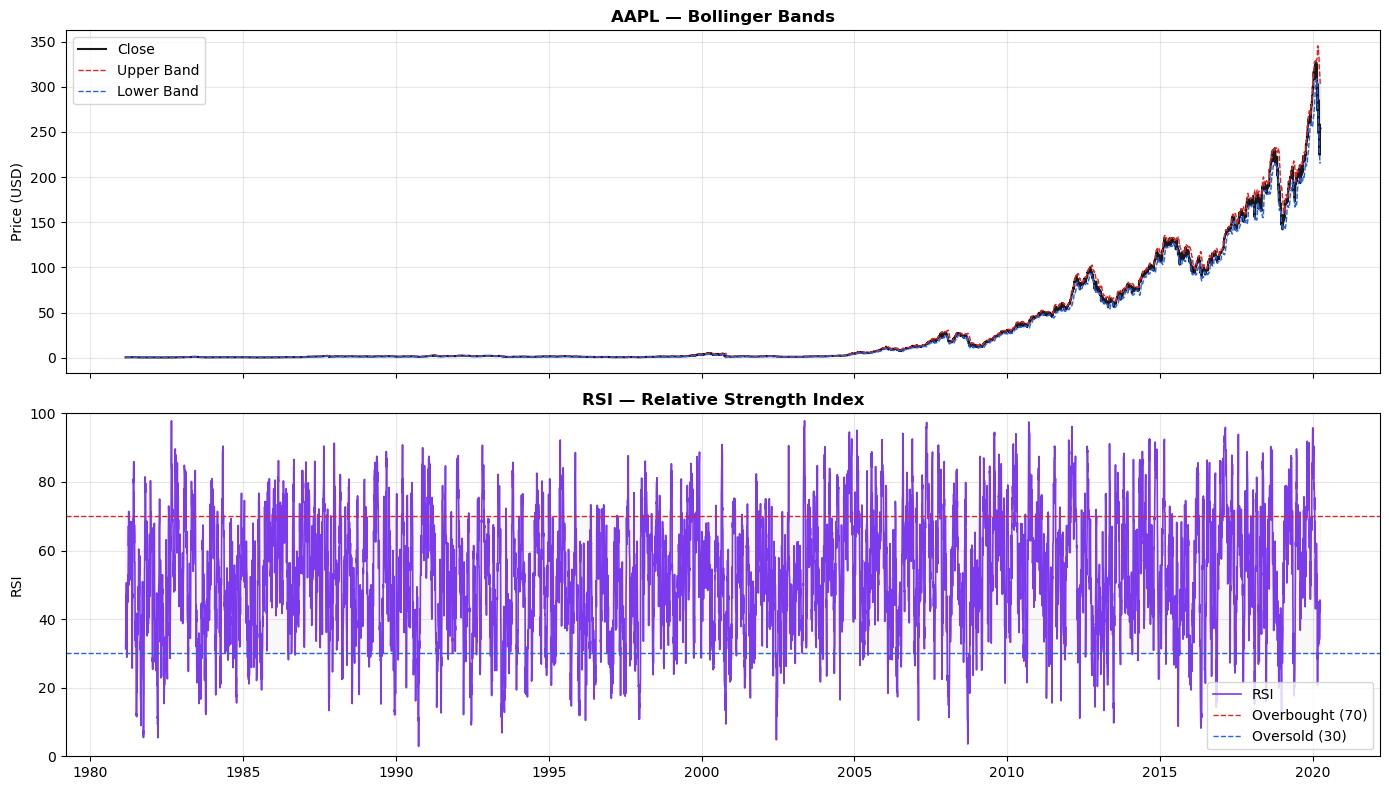

In [32]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Bollinger Bands
ax1.plot(df2.index, df2['Close'],    color='#18181B', lw=1.5, label='Close')
ax1.plot(df2.index, df2['BB_upper'], color='#DC2626', lw=1,   linestyle='--', label='Upper Band')
ax1.plot(df2.index, df2['BB_lower'], color='#2563EB', lw=1,   linestyle='--', label='Lower Band')
ax1.fill_between(df2.index, df2['BB_lower'], df2['BB_upper'], alpha=0.1, color='gray')
ax1.set_title(f'{ticker} — Bollinger Bands', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(alpha=0.3)

# RSI
ax2.plot(df2.index, df2['RSI'], color='#7C3AED', lw=1.2, label='RSI')
ax2.axhline(70, color='#DC2626', lw=1, linestyle='--', label='Overbought (70)')
ax2.axhline(30, color='#2563EB', lw=1, linestyle='--', label='Oversold (30)')
ax2.fill_between(df2.index, 30, 70, alpha=0.05, color='gray')
ax2.set_title('RSI — Relative Strength Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/rsi_bollinger.png', dpi=300, bbox_inches='tight')
plt.show()

## 11- Final Summary

In [33]:
import joblib

# Save Linear Regression model
joblib.dump(lr_model, 'models/lr_final.pkl')
print('Linear Regression model saved to models/lr_final.pkl')

# Save LSTM model
lstm_model.save('models/lstm_final.keras')
print('LSTM model saved to models/lstm_final.keras')

# Save scalers
joblib.dump(scaler_X, 'models/scaler_X.pkl')
joblib.dump(scaler_y, 'models/scaler_y.pkl')
print('Scalers saved to models/')

Linear Regression model saved to models/lr_final.pkl
LSTM model saved to models/lstm_final.keras
Scalers saved to models/


In [34]:
# Final summary
print('=' * 50)
print(f'   STOCK PRICE PREDICTION — FINAL SUMMARY')
print('=' * 50)
print(f'  Ticker         : {ticker}')
print(f'  Date Range     : 2019-01-01 to 2024-12-31')
print(f'  Total Features : {len(feature_cols)}')
print(f'  Lookback Window: {LOOKBACK} days')
print()
print('  MODEL RESULTS:')
print(f'  Linear Regression — MAE: ${lr_mae:.2f} | RMSE: ${lr_rmse:.2f} | MAPE: {lr_mape:.2f}%')
print(f'  LSTM              — MAE: ${lstm_mae:.2f} | RMSE: ${lstm_rmse:.2f} | MAPE: {lstm_mape:.2f}%')
print()
best = 'LSTM' if lstm_mae < lr_mae else 'Linear Regression'
print(f'  Best Model: {best}')
print('=' * 50)

   STOCK PRICE PREDICTION — FINAL SUMMARY
  Ticker         : AAPL
  Date Range     : 2019-01-01 to 2024-12-31
  Total Features : 22
  Lookback Window: 60 days

  MODEL RESULTS:
  Linear Regression — MAE: $1.78 | RMSE: $3.08 | MAPE: 1.27%
  LSTM              — MAE: $54.56 | RMSE: $69.03 | MAPE: 35.10%

  Best Model: Linear Regression
